# **Evaluación del Modelo**

En este notebook evaluamos el rendimiento final de la CNN sobre el conjunto
de test, que no ha sido visto durante el entrenamiento ni la validación.
Esta es la estimación honesta de cómo se comportaría el modelo con datos reales.

Cargamos el modelo guardado en el notebook anterior para hacer la evaluación
de forma independiente.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#from google.colab import drive
#drive.mount('/content/drive')
#os.chdir("/content/drive/MyDrive/Colab Notebooks/ECGAssistant_Sprint1")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Mounted at /content/drive
Dispositivo: cpu


## 1. Carga del modelo y los datos

In [2]:
# Definimos la arquitectura (necesaria para cargar los pesos)
class ECG_CNN(nn.Module):

    def __init__(self):
        super(ECG_CNN, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool    = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(32 * 72, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


# Cargamos los pesos guardados
model = ECG_CNN().to(device)
model.load_state_dict(torch.load("ecg_cnn.pt", map_location=device))
model.eval()
print("Modelo cargado correctamente")

Modelo cargado correctamente


In [3]:
# Cargamos los datos de test
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

from torch.utils.data import TensorDataset, DataLoader
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

print(f"Muestras de test: {X_test.shape[0]}")

Muestras de test: 14748


## 2. Predicciones sobre el conjunto de test

Una vez entrenado el modelo, lo evaluamos sobre el conjunto de test,
que no ha visto durante el entrenamiento. Así obtenemos una estimación
real de cómo se comportaría con datos nuevos.

In [4]:
test_preds, test_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = torch.argmax(model(xb), dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(yb.cpu().numpy())

print(f"F1 en test: {f1_score(test_true, test_preds):.4f}")
print()
print(classification_report(
    test_true, test_preds,
    target_names=["Normal", "Anormal"]
))

F1 en test: 0.9867

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     10449
     Anormal       0.99      0.99      0.99      4299

    accuracy                           0.99     14748
   macro avg       0.99      0.99      0.99     14748
weighted avg       0.99      0.99      0.99     14748



## 3. Matriz de confusión

El classification report está bien pero nos resulta más fácil ver los
errores visualmente. La matriz nos permite identificar de un vistazo
cuántas arritmias se escaparon (falsos negativos), que en este contexto
son los errores más problemáticos.

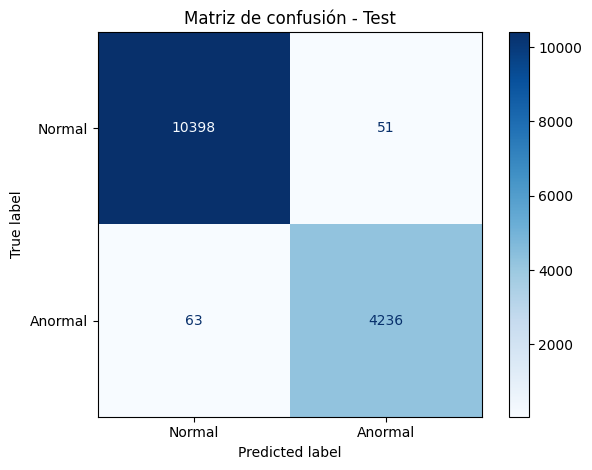

Arritmias detectadas correctamente (TP): 4,236
Arritmias que se escaparon       (FN): 63  ← los más críticos
Falsas alarmas                   (FP): 51
Normales correctos               (TN): 10,398


In [5]:
cm   = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anormal"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Test")
plt.tight_layout()
plt.show()

# Desglose de errores
tn, fp, fn, tp = cm.ravel()
print(f"Arritmias detectadas correctamente (TP): {tp:,}")
print(f"Arritmias que se escaparon       (FN): {fn:,}  ← los más críticos")
print(f"Falsas alarmas                   (FP): {fp:,}")
print(f"Normales correctos               (TN): {tn:,}")

## 4. Curva ROC y AUC

La curva ROC muestra la relación entre la tasa de verdaderos positivos
(recall) y la tasa de falsos positivos para distintos umbrales de
clasificación. El AUC (área bajo la curva) resume en un solo número
la capacidad discriminativa del modelo: 1.0 es perfecto, 0.5 es
equivalente a clasificar aleatoriamente.

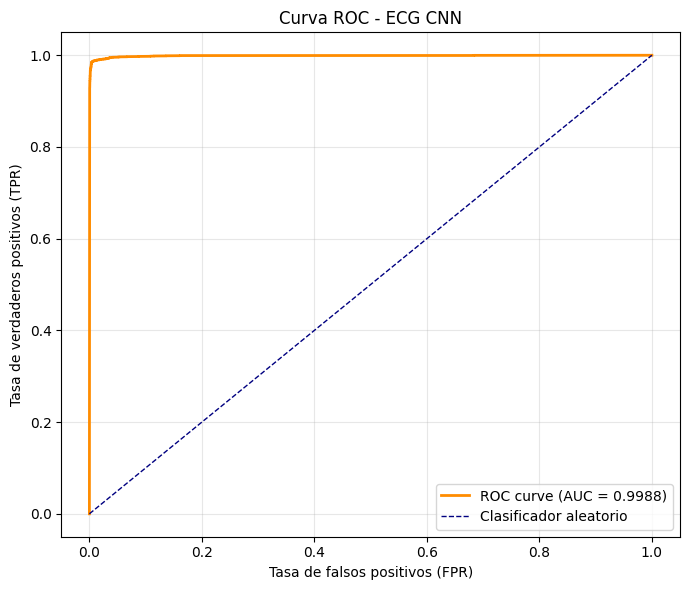

AUC: 0.9988


In [6]:
from sklearn.metrics import roc_curve, auc

# Necesitamos las probabilidades, no solo las clases predichas
probs_all = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)
        probs_all.extend(probs[:, 1].cpu().numpy())  # probabilidad clase anormal

# Calculamos la curva ROC
fpr, tpr, thresholds = roc_curve(test_true, probs_all)
roc_auc = auc(fpr, tpr)

# Visualizamos
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - ECG CNN")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")

## Reflexión de los resultados

El modelo obtiene un F1 de 0.9867 en test, prácticamente idéntico al de
validación (0.9874), lo que confirma que generaliza perfectamente a datos
nuevos sin overfitting.

El resultado es especialmente bueno en ambas clases: tanto Normal como
Anormal obtienen precisión, recall y F1 de 0.99. En un contexto médico
lo más importante es el recall de la clase anormal, que indica que el
modelo detecta el 99% de las arritmias reales.

De las 4.299 arritmias del test el modelo solo se escapa 63, un 1.5%.
Las falsas alarmas son únicamente 51, un resultado muy bajo que significa
que cuando el modelo dice que hay una arritmia casi siempre tiene razón.

Con una accuracy global del 99% sobre 14.748 muestras de test, el modelo
supera con creces el objetivo marcado de F1 ≥ 0.95 y demuestra ser una
base sólida para el pipeline completo del sistema ECGAssistant.

El AUC de 0.9988 confirma que el modelo tiene una capacidad discriminativa
casi perfecta: es capaz de separar latidos normales y anormales con un
99.88% de fiabilidad independientemente del umbral de clasificación elegido.